<img src="media/Banner_waterlevel+esalogo.svg" width="100%" alt="Banner for EO AFRICA course" />


*R. Rietbroek, May 2026*

<font color=#cf0072>

# Empirical rating curves from radar altimetry and Geoglows output
</font>

<font color=#cf0072>
    
## Introduction and goal of the tutorial
One possibility to get an (empirical) idea of the stage-discharge rating curve is to use observed water heights and discharge.


In this tutorial, you'll use radar altimetry water level estimates at virtual station locations from the Dahiti database, and pair them with *modelled* discharge from the [GEOGLOWS model](https://www.geoglows.org/).  

For selected locations a empirical rating curve can then be constructed. You'll be asked to furthre reflect realism of the rating curve and the error sources associated with it.

## Step 1 

</font>

In [51]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
import xarray as xr
import geopandas as gpd
from glob import glob
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt
import folium

from pyaltim.portals.dahiti import DahitiConnect
import os

<font color=#cf0072>

## Step 2: Load the linkage between geoglows reaches and the virtual stations (VS)
</font>


In [53]:
## ANSWER MODEL STEP 3
linkage_gpkg_file='../data/af_geoglows_altimetry_link.gpkg'

dflinks=gpd.read_file(linkage_gpkg_file)

targetobj='Rufiji, River'

dftarget=dflinks[ (dflinks.target_name == targetobj) & (dflinks.geoglows_linkno)]

display(dftarget)


/home/eoafrica/resources/F2FDar26/pywater/lib/python3.14/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'af_geoglows_altimetry_link.gpkg': 'dahiti_vs' (default), 'geoglows'. Specify layer parameter to avoid this warning.
  result = read_func(


,id,dahiti_id,target_name,location,continent,country,type,data_access,geoglows_linkno,geom_reach,geometry
2402,8200,11703,"Rufiji, River",NaN,Africa,Tanzania,River,water_level_altimetry:public,110529763.0,MULTILINESTRING((38.18244444444346 -7.73733333...,POINT (38.1934 -7.7479)
2403,8200,11703,"Rufiji, River",NaN,Africa,Tanzania,River,water_level_altimetry:public,110531075.0,LINESTRING(38.20555555555457 -7.75555555555070...,POINT (38.1934 -7.7479)
2404,8201,11937,"Rufiji, River",NaN,Africa,Tanzania,River,water_level_altimetry:public,110353963.0,LINESTRING(38.87511111111004 -8.00055555555067...,POINT (38.8724 -8.0011)
2405,8201,11937,"Rufiji, River",NaN,Africa,Tanzania,River,water_level_altimetry:public,110524522.0,LINESTRING(38.87511111111004 -8.00055555555067...,POINT (38.8724 -8.0011)
2406,8201,11937,"Rufiji, River",NaN,Africa,Tanzania,River,water_level_altimetry:public,110525834.0,LINESTRING(38.9397777777767 -8.014555555550672...,POINT (38.8724 -8.0011)
2407,8202,16683,"Rufiji, River",NaN,Africa,Tanzania,River,water_level_altimetry:public,110478610.0,LINESTRING(37.54544444444354 -8.26111111110619...,POINT (37.5334 -8.2861)
2408,8203,16938,"Rufiji, River",NaN,Africa,Tanzania,River,water_level_altimetry:public,110508784.0,LINESTRING(37.632999999999086 -8.1782222222173...,POINT (37.6248 -8.1967)
2409,8204,17314,"Rufiji, River",NaN,Africa,Tanzania,River,water_level_altimetry:public,110533703.0,LINESTRING(38.62433333333229 -7.93299999999512...,POINT (38.6211 -7.9234)
2410,8205,23974,"Rufiji, River",NaN,Africa,Tanzania,River,water_level_altimetry:public,110528458.0,LINESTRING(39.24855555555443 -8.02511111110622...,POINT (39.0615 -8.0494)


<font color=#cf0072>

## Step 3: Load the Dahiti altimetry data (using API or from file cache)
</font>


In [54]:
dirdahiti='../data/Dahiti_wl'

def get_wlfile(dahiti_id):
    return os.path.join(dirdahiti,f"wl_dahiti_{dahiti_id}.nc")

In [57]:
#loop over the dahiti_id's
dahiti_wl={}
dahiti_conn=None


if not os.path.exists(dirdahiti):
    os.makedirs(dirdahiti)
    for dahiti_id in dftarget.dahiti_id:
        print(f"getting {dahiti_id}") 
        try:
            if dahiti_conn is None:
                dahiti_conn=DahitiConnect()
                
            info,ds=dahiti_conn.get_waterlevel(dahiti_id)
            del info['location']
            ds.attrs=info
            dahiti_wl[dahiti_id]=ds
            #also save to netcdf file
            fout=get_wlfile(dahiti_id)
            print(f"saving to {fout}")
            ds.to_netcdf(fout)    
        except KeyError:
            print(f"No data found for {dahiti_id}, trying next")
else:
    #load from files
    for fin in glob(f"{dirdahiti}/*nc"):
        print(f"loading data from cache {fin}")
        ds=xr.open_dataset(fin)
        dahiti_wl[ds.attrs['dahiti_id']]=ds

    

loading data from cache ../data/Dahiti_wl/wl_dahiti_17314.nc
loading data from cache ../data/Dahiti_wl/wl_dahiti_11703.nc
loading data from cache ../data/Dahiti_wl/wl_dahiti_16938.nc
loading data from cache ../data/Dahiti_wl/wl_dahiti_16683.nc
loading data from cache ../data/Dahiti_wl/wl_dahiti_23974.nc
loading data from cache ../data/Dahiti_wl/wl_dahiti_11937.nc


In [56]:
dahiti_wl.keys()

dict_keys([np.int64(17314), np.int64(11703), np.int64(16938), np.int64(16683), np.int64(23974), np.int64(11937)])

<font color=#cf0072>

## Step 4: Load Geoglows daily retrospective data from online zarr bucket or file cache
</font>


In [37]:
# load geoglows data from online resource
# see https://training.geoglows.org/rfs/datasets/catalog/ for products

geoglowsfile='../data/geoglows_rufiji.nc'

if not os.path.exists(geoglowsfile):
    print("retrieve geoglows from online s3 bucket")
    zarr_uri='s3://geoglows-v2/retrospective/daily.zarr'
    dsgeoglows = xr.open_dataset(zarr_uri, engine='zarr', storage_options={'anon': True}).sel(river_id=dftarget.geoglows_linkno.values)
    dsgeoglows.to_netcdf(geoglowsfile)
else:
    print("retrieve geoglows from cached file")
    dsgeoglows=xr.open_dataset(geoglowsfile)



display(dsgeoglows)

retrieve geoglows from cached file


<xarray.Dataset> Size: 1MB
Dimensions:   (time: 31546, river_id: 9)
Coordinates:
  * time      (time) datetime64[ns] 252kB 1940-01-01 1940-01-02 ... 2026-05-14
  * river_id  (river_id) int32 36B 110529763 110531075 ... 110533703 110528458
Data variables:
    Q         (time, river_id) float32 1MB ...

<font color=#cf0072>

## Step 5: Interpolate Geoglows data on dahiti time points
</font>


In [66]:
# create dahiti/geoglows pairs by means of interpolating the geoglows to the altimetry time tags
for dahiti_id,dsalt in dahiti_wl.items():
    #get the corresponding geoglows link  no
    print(dahiti_id)
    linkrow=dftarget[dftarget.dahiti_id == dahiti_id].iloc[0] # note take the first row (there may be more matches)
    #add the interpolated geoglows data to the Dahiti dataset
    dahiti_wl[dahiti_id]['Q_geoglows']=dsgeoglows.Q.sel(river_id=linkrow.geoglows_linkno).interp(time=dahiti_wl[dahiti_id].time.data)





17314
11703
16938
16683
23974
11937


<font color=#cf0072>

## Step 6: Visualize virtual station locations and reaches
</font>


In [104]:
from shapely.geometry import Point
import folium
from shapely.wkt import loads

dahiti_id=11937



plotcenter=Point(38.5538,-7.8797)


m = folium.Map(location=[plotcenter.y, plotcenter.x], zoom_start=8)

for grp,rows in dftarget.groupby('dahiti_id'):
    r=rows.iloc[0]
    # print(loads(df.geom_reach)):
    folium.Marker(
        location=[r.geometry.y, r.geometry.x],
        popup=f"Dahiti_id: {r['dahiti_id']}").add_to(m)

    #also plot reach
    reach=loads(r.geom_reach)
    folium.GeoJson(reach,color='red').add_to(m)
   
display(m)

<font color=#cf0072>

## Step 7: Visualize empirical rating curves
</font>


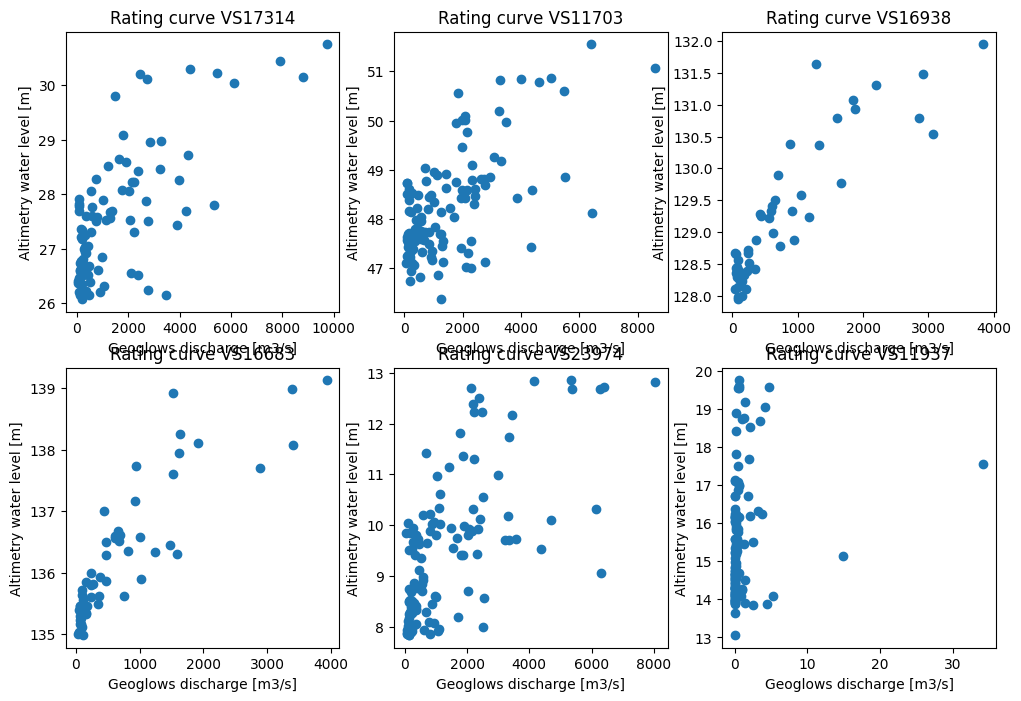

In [73]:
fig,axes=plt.subplots(nrows=2,ncols=3,figsize=(12,8))


for ax, (dahiti_id,dspair) in zip(axes.flatten(),dahiti_wl.items()):
    ax.scatter(dspair.Q_geoglows,dspair.water_level)
    ax.set_ylabel('Altimetry water level [m]')
    ax.set_xlabel('Geoglows discharge [m3/s]')
    ax.set_title(f'Rating curve VS_{dahiti_id}')





<font color=#cf0072>

## Step 8: Reflect on potential error sources, and come up with a list of potential improvements for generating better rating curves
</font>
